# Protein Design Pipeline — End-to-End

This notebook is a presentation-style overview of the full protein design workflow. It does **not** generate new data. It only loads final outputs from earlier notebooks and arranges them into a clear project story.


In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

# Robust path handling
BASE_DIR = Path('..')
if not (BASE_DIR / 'results').exists():
    BASE_DIR = Path('.')

TABLES_DIR = BASE_DIR / 'results' / 'tables'
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
DATA_DIR = BASE_DIR / 'data'

print('Using BASE_DIR:', BASE_DIR)
print('Tables:', TABLES_DIR)
print('Figures:', FIGURES_DIR)


Using BASE_DIR: ..
Tables: ../results/tables
Figures: ../results/figures


## 1. Problem Definition

We aim to redesign a protein starting from a known structure (**1LYZ**) and identify improved candidates using computational methods.

This project integrates:

- structure-guided sequence redesign (ProteinMPNN)
- structure prediction (AlphaFold / ColabFold)
- structural comparison (RMSD)
- energy evaluation (FoldX)
- multi-metric candidate ranking

The final goal is to identify candidates that balance:

- low mutation burden
- high structural confidence
- structural similarity to native
- acceptable energetic plausibility


## 2. Structure Analysis

This stage focuses on understanding the starting protein structure.

Main tasks:

- parsing the 1LYZ structure
- extracting the sequence
- building a residue-level feature table
- identifying structural context such as core/surface and secondary structure


In [13]:
residue_file = DATA_DIR / 'processed' / 'residue_table.csv'

if residue_file.exists():
    residue_df = pd.read_csv(residue_file)
    residue_df.head()
else:
    print('Residue table not found:', residue_file)
    
residue_df.head()

,chain_id,residue_number,insertion_code,residue_name_3,residue_name_1,has_N,has_CA,has_C,has_O,ca_x,...,ca_z,dist_from_centroid,environment,seq_index,ss_simple,is_special_residue,mutation_priority,mutation_priority_reason,aa_class,aa_charge_class
0,A,1,NaN,Lys,K,True,True,True,True,2.439,...,9.791,14.148950,surface,0,loop,False,high,surface;loop,positive,positive
1,A,2,NaN,Val,V,True,True,True,True,2.307,...,7.580,13.469238,surface,1,helix,False,high,surface;helix,hydrophobic,neutral
2,A,3,NaN,Phe,F,True,True,True,True,-1.187,...,7.580,12.696476,core,2,sheet,False,low,core;sheet,aromatic,neutral
3,A,4,NaN,Gly,G,True,True,True,True,-2.637,...,4.864,14.780398,surface,3,sheet,True,low,surface;sheet;special_residue,special,neutral
4,A,5,NaN,Arg,R,True,True,True,True,-3.823,...,5.685,13.922536,surface,4,helix,False,high,surface;helix,positive,positive


### Key observation

The starting structure was successfully converted into a residue-level table, which provided the basis for later mutation analysis and design constraints.


## 3. Design Preparation

This stage prepared the structure and sequence inputs required for ProteinMPNN.

Main tasks:

- cleaning the input structure
- preparing sequence-compatible input
- generating design-ready files for computational redesign


In [4]:
clean_pdb = DATA_DIR / 'design' / '1LYZ_clean.pdb'

if clean_pdb.exists():
    print('Clean structure found:', clean_pdb)
else:
    print('Clean structure not found:', clean_pdb)


Clean structure found: ../data/design/1LYZ_clean.pdb


### Key observation

The input structure was cleaned and prepared for downstream sequence redesign using ProteinMPNN.


## 4. ProteinMPNN Design

ProteinMPNN was used to generate redesigned protein sequences from the reference structure.

Main tasks:

- generate multiple redesigned sequences
- compare mutation burden
- identify candidate sequences for structural validation


In [14]:
design_file = TABLES_DIR / 'selected_candidates.csv'

if design_file.exists():
    design_df = pd.read_csv(design_file)
    design_df.head()
else:
    print('Design file not found:', design_file)

design_df.head()


,name,sequence,num_mutations,mutation_positions,mutations,id,file,plddt,ptm,rank_score,candidate_rank
0,">T=0.1, sample=1, score=0.8716, global_score=0...",MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...,70,"[1, 2, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ...",K1M;V2K;G4S;A10R;A11R;M12L;R14E;H15L;L17M;Y20L...,seq_1,../results/alphafold/seq_1_3e80b_scores_rank_0...,96.237209,0.90,93.742326,1
1,">T=0.1, sample=5, score=0.8566, global_score=0...",MKFSRCGLAQELKKLGMDNFNGYPLGAWVCLAEVTAGGDTSVSRAY...,67,"[1, 2, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21, 2...",K1M;V2K;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L17M;...,seq_5,../results/alphafold/seq_5_55760_scores_rank_0...,95.769535,0.89,93.061721,2
2,">T=0.1, sample=2, score=0.8667, global_score=0...",KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...,73,"[2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21, 2...",V2K;F3Y;G4T;E7G;A10K;A11E;M12L;R14K;H15L;L17M;...,seq_2,../results/alphafold/seq_2_a3008_scores_rank_0...,95.363643,0.89,92.818186,3
3,">T=0.1, sample=4, score=0.8506, global_score=0...",KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...,70,"[2, 3, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ...",V2K;F3Y;G4S;A10Q;A11T;M12L;R14K;H15L;L17M;Y20F...,seq_4,../results/alphafold/seq_4_01504_scores_rank_0...,95.135736,0.89,92.681442,4
4,">T=0.1, sample=3, score=0.9082, global_score=0...",MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...,76,"[1, 2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21...",K1M;V2K;F3Y;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L...,seq_3,../results/alphafold/seq_3_76161_scores_rank_0...,91.259147,0.87,89.555488,5


### Key observation

Round 1 explored sequence space broadly but introduced high mutation burden.


## 5. Structure Validation (AlphaFold)

Top redesign candidates were evaluated using AlphaFold-based structure prediction.

Main metrics:

- pLDDT
- pTM


In [16]:
validation_file = TABLES_DIR / 'design_validation.csv'

if validation_file.exists():
    validation_df = pd.read_csv(validation_file)
    validation_df[['plddt', 'ptm']].describe()
else:
    print('Validation file not found:', validation_file)

validation_df[['plddt', 'ptm']].describe()


,plddt,ptm
count,6.000000,6.000000
mean,95.312016,0.891667
std,2.251032,0.013292
min,91.259147,0.870000
25%,95.192713,0.890000
50%,95.566589,0.890000
75%,96.120291,0.897500
max,98.106822,0.910000


### Key observation

Despite large sequence changes in round 1, predicted structures retained high confidence, indicating that many redesigns remained compatible with the original fold.


## 6. Scoring and Ranking

Candidates were compared using:

- C-alpha RMSD to the reference structure
- FoldX total energy
- integrated multi-metric ranking


In [17]:
ranking_file = TABLES_DIR / 'final_candidate_ranking.csv'

if ranking_file.exists():
    rank_df = pd.read_csv(ranking_file)
    rank_df.head()
else:
    print('Ranking file not found:', ranking_file)

rank_df.head()

,round,candidate_key,name,candidate_rank,sequence,num_mutations,mutations,plddt,ptm,ca_rmsd,total_energy,plddt_score,ptm_score,mutation_score,rmsd_score,foldx_score,final_score
0,round2_constrained,round2_rank_2,"T=0.1,",2,MVWGQCELAAALKKHGMDNYRGYSLGNFVCLAKFESNFNNSVTNTN...,31,K1M;F3W;R5Q;M12L;R14K;L17M;W28F;A31L;T40N;Q41S...,97.993256,0.91,0.726553,-3.65322,1.000000,1.00,0.937500,0.891856,0.594061,0.904980
1,round2_constrained,round2_rank_4,"T=0.1,",4,KVFGRCELAAALKKHGMDNFRGYSLGNWVCLAKFESNFNTSVSNTN...,28,M12L;R14K;L17M;Y20F;A31L;Q41S;A42V;T43S;R45T;I...,97.055659,0.90,0.713334,1.97199,0.860769,0.75,1.000000,0.923918,0.366600,0.804966
2,round2_constrained,round2_rank_6,"T=0.1,",6,MVFGQCELAAALKKHGMDNFRGYSLGNFVCLAKFESNFNNTVSNTN...,31,K1M;R5Q;M12L;R14K;L17M;Y20F;W28F;A31L;T40N;Q41...,97.374264,0.90,0.708983,5.13842,0.908081,0.75,0.937500,0.934471,0.238563,0.787199
3,round2_constrained,round2_rank_5,"T=0.1,",5,KVWGTCELAAALKKHGMDNFRGYSLGNYVCLAKFESNFNNSVSNTN...,32,F3W;R5T;M12L;R14K;L17M;Y20F;W28Y;A31L;T40N;Q41...,97.414419,0.90,0.683969,11.03820,0.914044,0.75,0.916667,0.995137,0.000000,0.760872
4,round2_constrained,round2_rank_3,"T=0.1,",3,TVWGQCELAAALKKHGMDNFRGYSLGNFVCLAKFESNFNNSVSNTN...,32,K1T;F3W;R5Q;M12L;R14K;L17M;Y20F;W28F;A31L;T40N...,97.524341,0.90,0.738384,9.28778,0.930367,0.75,0.916667,0.863161,0.070780,0.749174


### Key observation

Ranking integrated multiple metrics rather than relying on a single score, allowing more balanced candidate selection.


## 7. Constrained Redesign (Round 2)

A second redesign round was performed after identifying risky mutations and structurally sensitive positions.

Main goals:

- reduce mutation burden
- improve structural consistency
- preserve fold quality


In [18]:
summary_file = TABLES_DIR / 'final_candidate_master_summary.csv'

if summary_file.exists():
    summary_df = pd.read_csv(summary_file)
    summary_df
else:
    print('Summary file not found:', summary_file)

summary_df


,round,n_candidates,mean_mutations,mean_plddt,mean_ptm,mean_rmsd,mean_foldx
0,round1_unconstrained,5,71.2,94.753054,0.888,0.829452,-6.063698
1,round2_constrained,5,30.8,97.472388,0.902,0.714245,4.756634


### Key observation

Constrained redesign substantially reduced mutation burden and improved structural confidence and RMSD, although FoldX energies became less favorable on average.


## 8. Final Candidate Table

All evaluation metrics were merged into a single candidate-level table for direct comparison across redesign rounds.


In [19]:
master_file = TABLES_DIR / 'final_candidate_master_table.csv'

if master_file.exists():
    master_df = pd.read_csv(master_file)
    master_df.head()
else:
    print('Master table not found:', master_file)

master_df.head()


,round,candidate_key,name,candidate_rank,sequence,num_mutations,mutations,plddt,ptm,ca_rmsd,total_energy
0,round1_unconstrained,seq_1_3e80b,">T=0.1, sample=1, score=0.8716, global_score=0...",1,MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...,70,K1M;V2K;G4S;A10R;A11R;M12L;R14E;H15L;L17M;Y20L...,96.237209,0.90,0.784212,-13.692300
1,round1_unconstrained,seq_5_55760,">T=0.1, sample=5, score=0.8566, global_score=0...",2,MKFSRCGLAQELKKLGMDNFNGYPLGAWVCLAEVTAGGDTSVSRAY...,67,K1M;V2K;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L17M;...,95.769535,0.89,0.681965,0.076024
2,round1_unconstrained,seq_2_a3008,">T=0.1, sample=2, score=0.8667, global_score=0...",3,KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...,73,V2K;F3Y;G4T;E7G;A10K;A11E;M12L;R14K;H15L;L17M;...,95.363643,0.89,1.094273,-9.198090
3,round1_unconstrained,seq_4_01504,">T=0.1, sample=4, score=0.8506, global_score=0...",4,KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...,70,V2K;F3Y;G4S;A10Q;A11T;M12L;R14K;H15L;L17M;Y20F...,95.135736,0.89,0.725156,-7.221200
4,round1_unconstrained,seq_3_76161,">T=0.1, sample=3, score=0.9082, global_score=0...",5,MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...,76,K1M;V2K;F3Y;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L...,91.259147,0.87,0.861658,-0.282924


## 9. Top Candidates

The final ranking identified the most balanced candidates across all metrics.


In [20]:
top_file = TABLES_DIR / 'top_final_candidates.csv'

if top_file.exists():
    top_candidates_df = pd.read_csv(top_file)
    top_candidates_df
else:
    print('Top candidates file not found:', top_file)

top_candidates_df


,round,candidate_key,name,candidate_rank,sequence,num_mutations,mutations,plddt,ptm,ca_rmsd,total_energy,plddt_score,ptm_score,mutation_score,rmsd_score,foldx_score,final_score
0,round2_constrained,round2_rank_2,"T=0.1,",2,MVWGQCELAAALKKHGMDNYRGYSLGNFVCLAKFESNFNNSVTNTN...,31,K1M;F3W;R5Q;M12L;R14K;L17M;W28F;A31L;T40N;Q41S...,97.993256,0.91,0.726553,-3.65322,1.000000,1.00,0.9375,0.891856,0.594061,0.904980
1,round2_constrained,round2_rank_4,"T=0.1,",4,KVFGRCELAAALKKHGMDNFRGYSLGNWVCLAKFESNFNTSVSNTN...,28,M12L;R14K;L17M;Y20F;A31L;Q41S;A42V;T43S;R45T;I...,97.055659,0.90,0.713334,1.97199,0.860769,0.75,1.0000,0.923918,0.366600,0.804966
2,round2_constrained,round2_rank_6,"T=0.1,",6,MVFGQCELAAALKKHGMDNFRGYSLGNFVCLAKFESNFNNTVSNTN...,31,K1M;R5Q;M12L;R14K;L17M;Y20F;W28F;A31L;T40N;Q41...,97.374264,0.90,0.708983,5.13842,0.908081,0.75,0.9375,0.934471,0.238563,0.787199


## 10. Visual Summary

Below are two compact plots that summarize the overall outcome of the workflow.


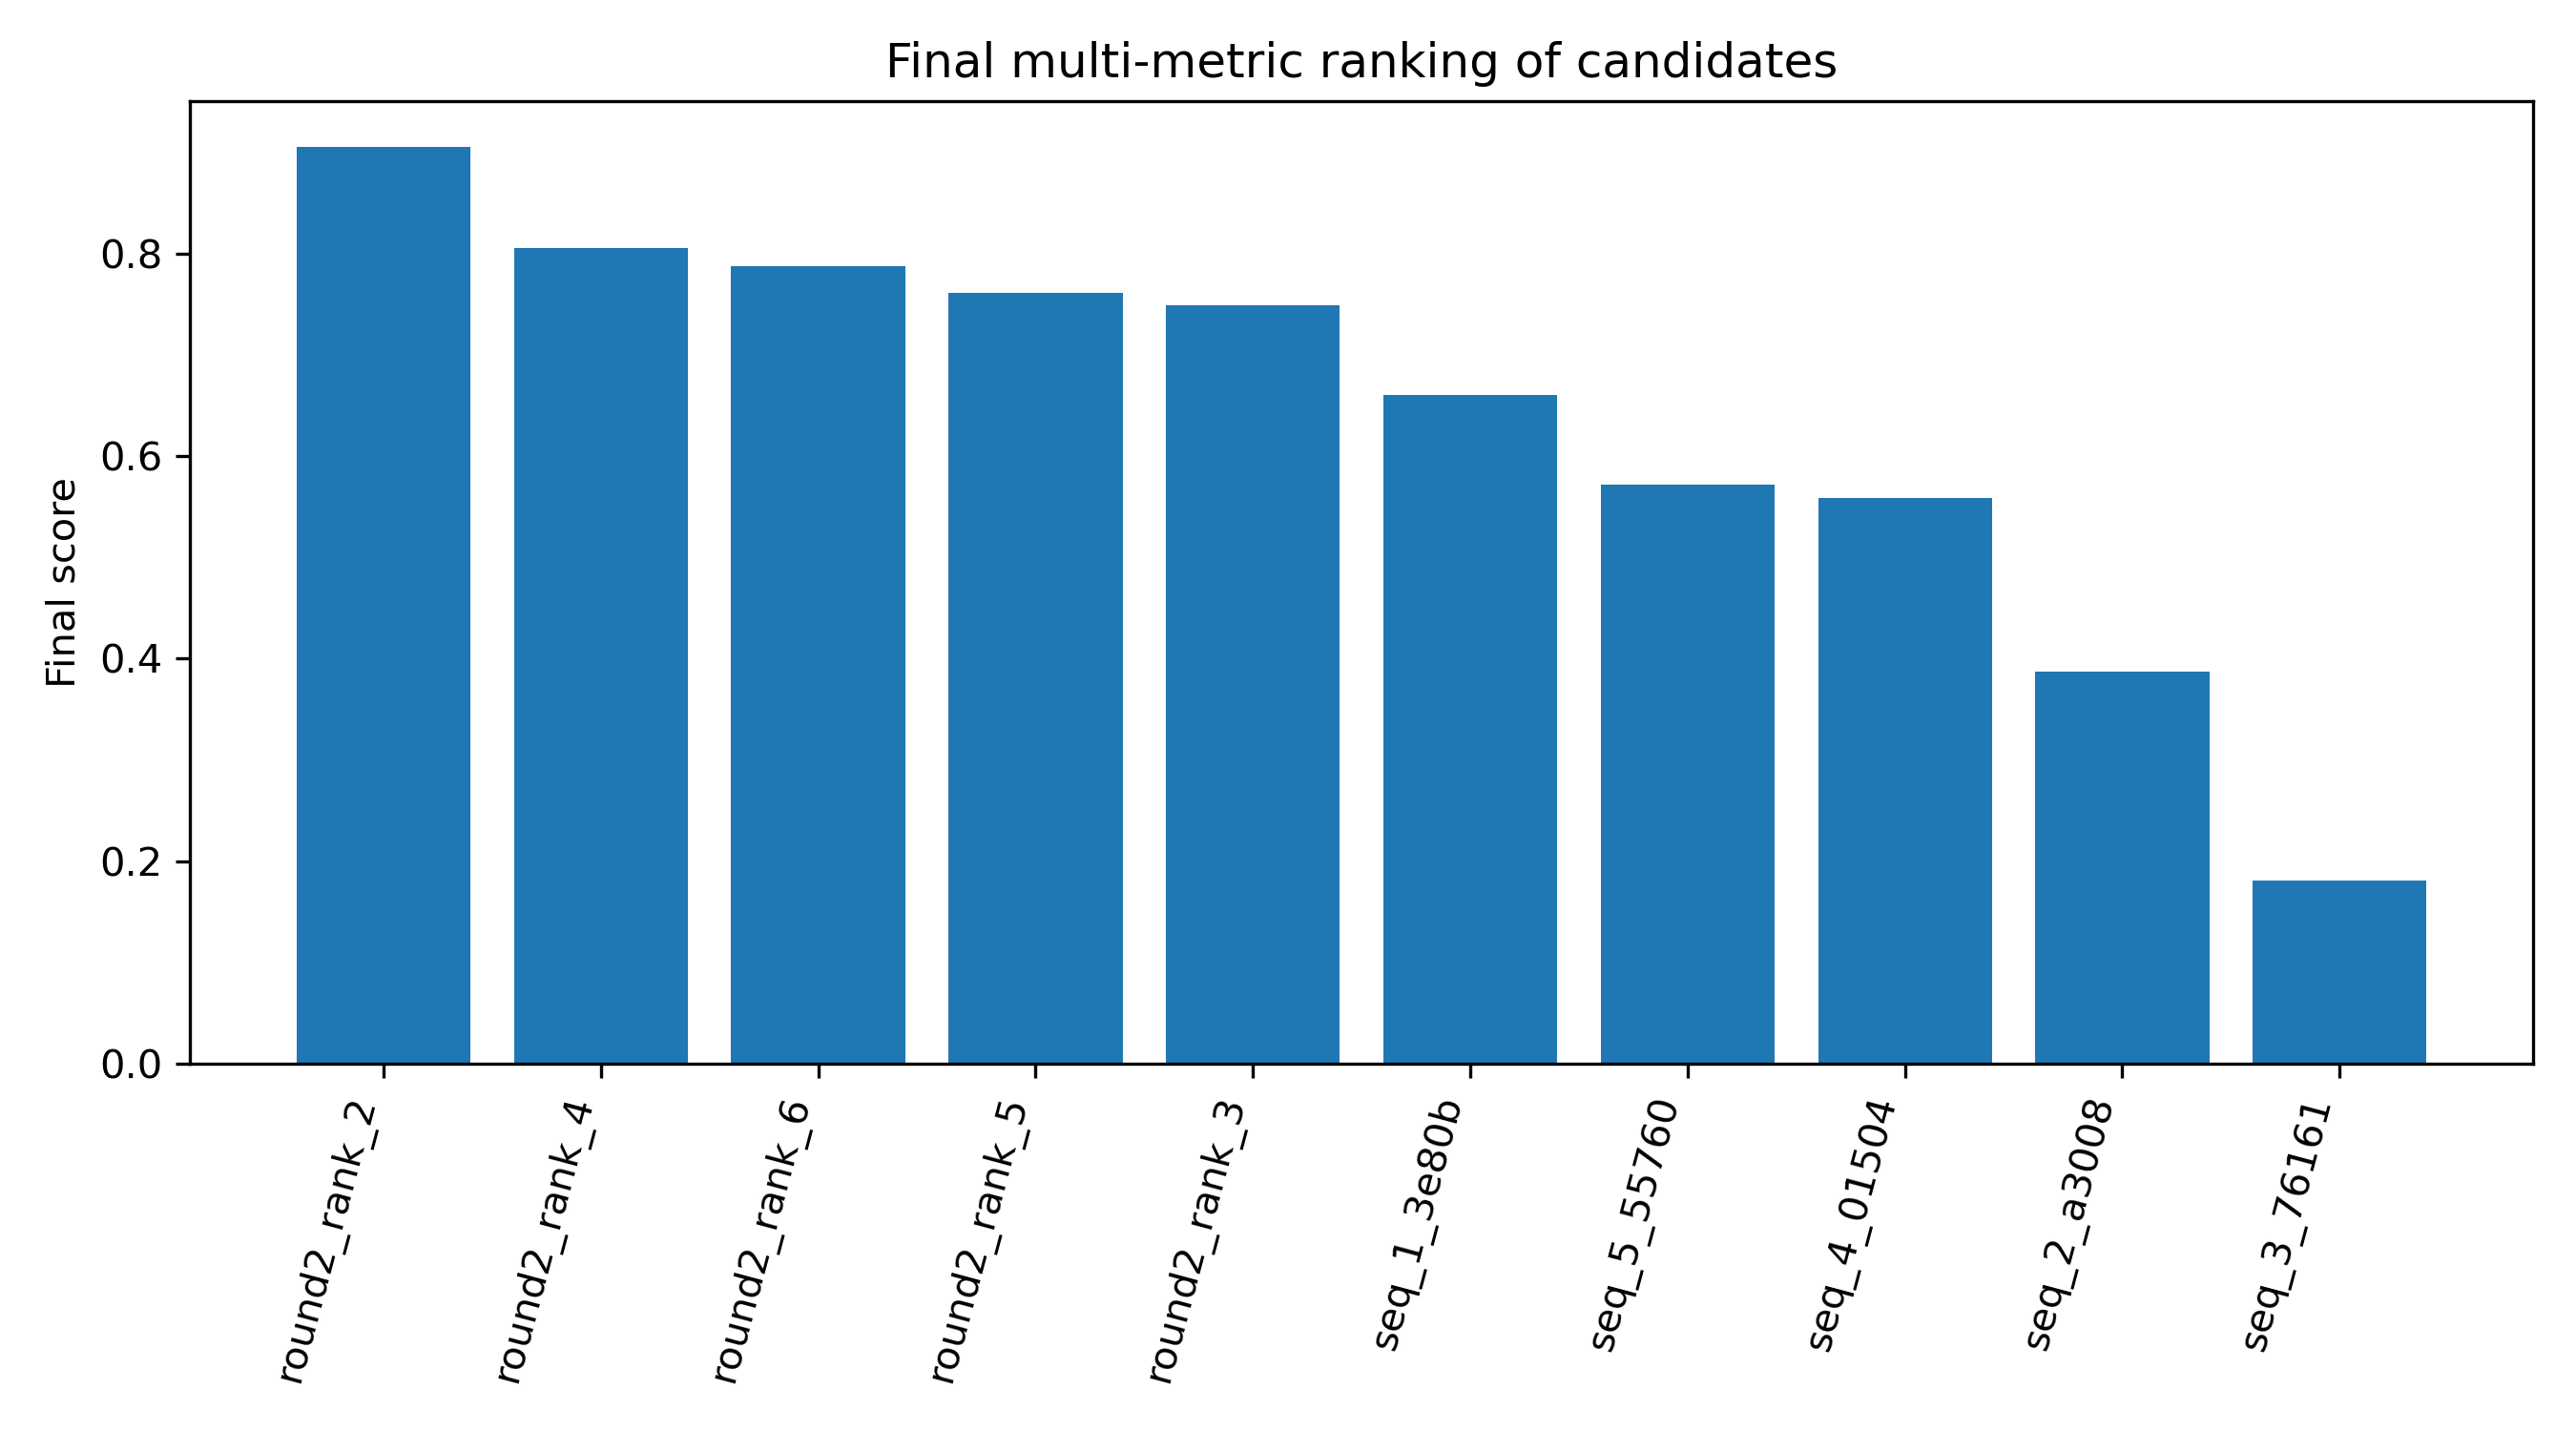

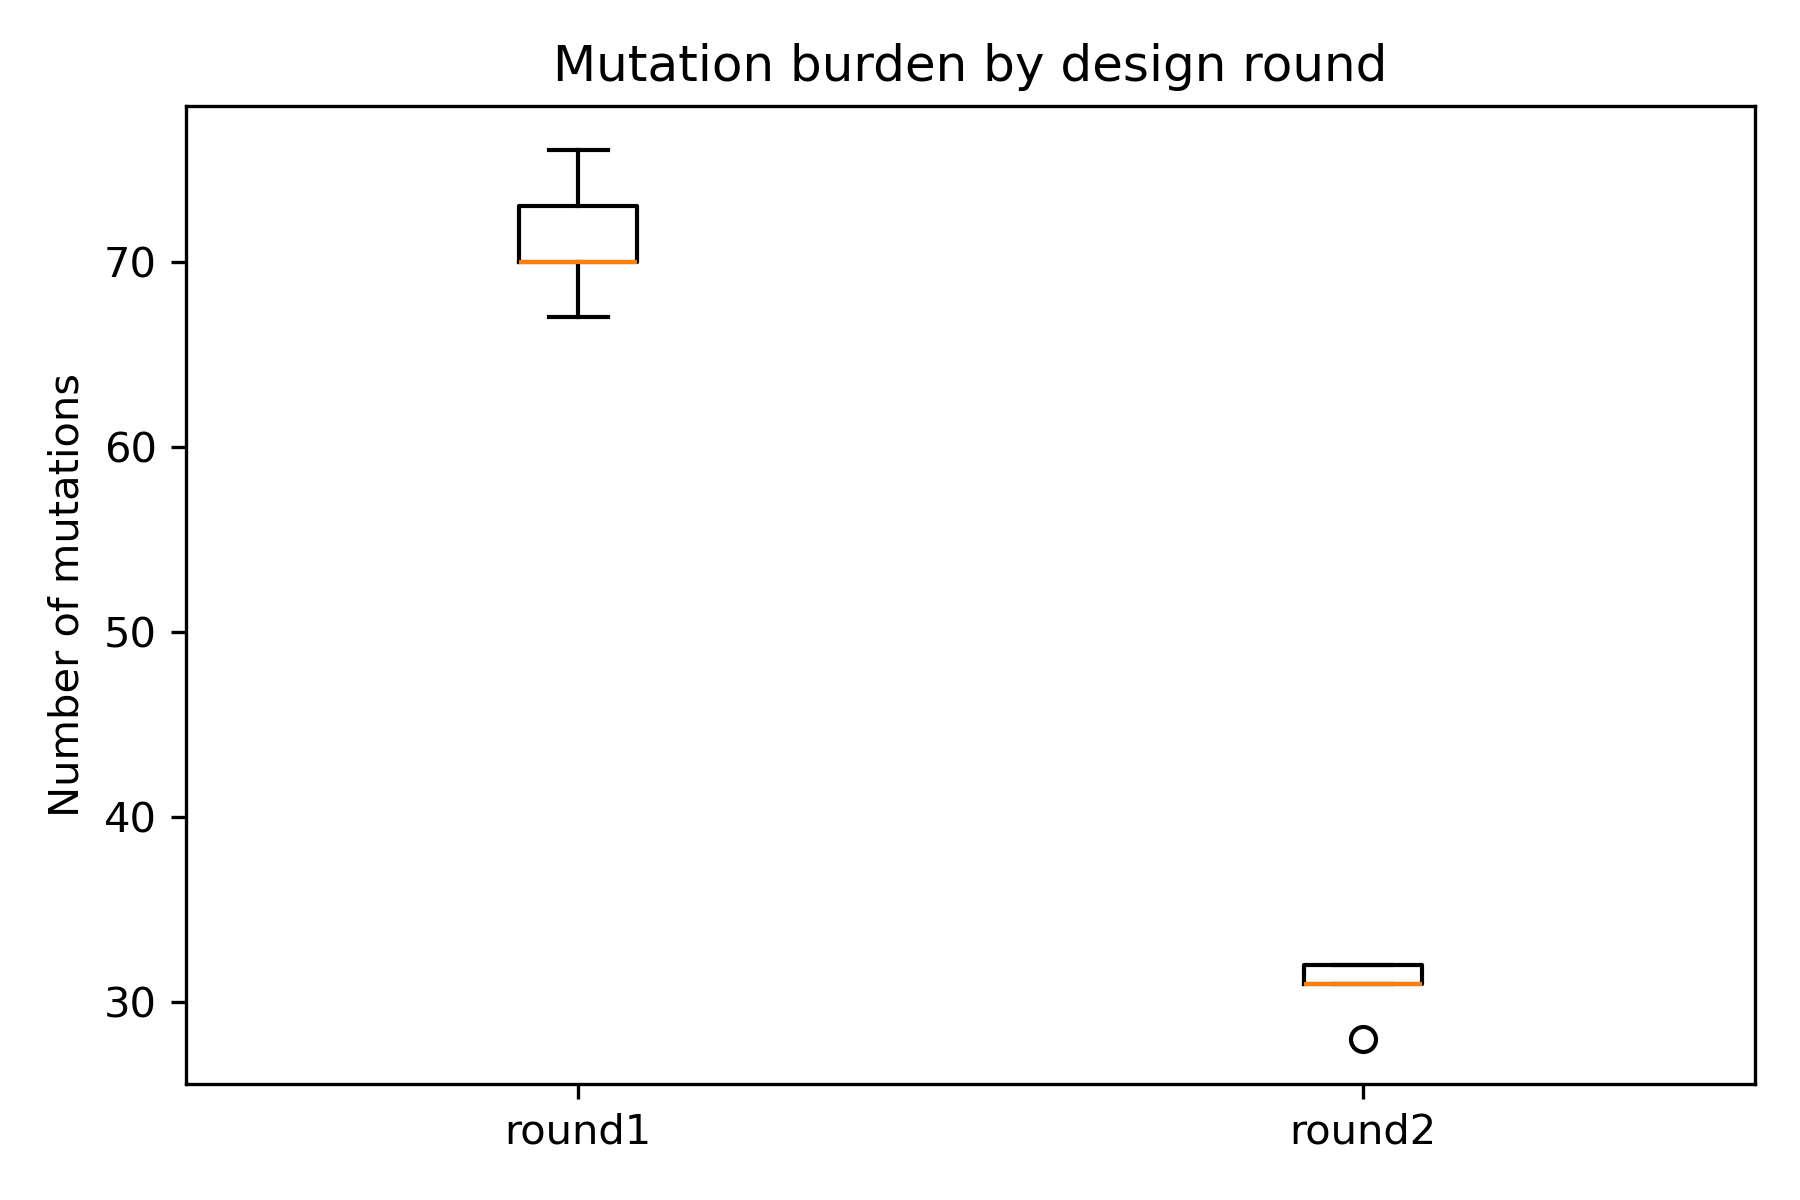

In [11]:
plot1 = FIGURES_DIR / 'plot_06_final_score_by_candidate.png'
plot2 = FIGURES_DIR / 'plot_01_mutation_burden_by_round.png'

for p in [plot1, plot2]:
    if p.exists():
        display(Image(filename=p))
    else:
        print('Missing plot:', p)


## 11. Final Interpretation

- mutation burden was significantly reduced in round 2
- structural confidence (pLDDT, pTM) improved
- RMSD decreased, indicating better structural agreement
- FoldX energy was more favorable in round 1

Overall interpretation:

Constrained redesign produced more balanced and realistic candidates by reducing unnecessary sequence change while improving structural consistency.


## 12. Conclusion

This workflow demonstrates a complete computational protein design pipeline integrating:

- sequence redesign
- structure prediction
- structural comparison
- energy evaluation
- multi-metric ranking

The final candidates represent a balance between structural fidelity, mutation control, and energetic plausibility.
